# Data Analysis Assignment - Solved
### Customer Churn Dataset (`exported_churn_data.csv`)


## ⚠️ Important Note on Dataset vs. Original Questions

The original question set was written for a **product/marketing engagement dataset** (columns like `Product`, `Views`, `Clicks`, `Likes`, `Rating`, `Purchase Value`, `Engagement Score`, `Campaign ID`).

The dataset actually provided — `exported_churn_data.csv` — is a **telecom subscription churn dataset** with a completely different schema (`customerid`, `subscription_type`, `plan_type`, `contract_type`, `monthly_charges`, `cltv`, `churn_score`, `csat_score`, `complaint_count`, `escalations`, etc.). There is no `Views`, `Clicks`, `Likes`, or `Campaign ID` column anywhere in this file, and no second dataset was provided to merge.

To still answer every question meaningfully, the following **column mapping / assumptions** are used throughout this notebook:

| Original concept | Mapped to (this dataset) | Notes |
|---|---|---|
| Product | `plan_type` (Basic / Standard / Premium) | Treated as the "product" being purchased |
| Rating | `csat_score` (Customer Satisfaction Score) | Only available for customers who filed a complaint (7 of 21 rows) |
| Purchase Value | `monthly_charges` | Amount paid per billing cycle |
| Engagement Score | `100 - churn_score` (derived) | Higher churn risk = lower engagement; genuine engagement metrics (views/clicks) don't exist in this data |
| Views / Clicks / Likes | **Not available** | Explicitly noted wherever this blocks a question; a reasonable substitute metric is used instead |
| Campaign ID / CTR | **Not available** | No campaign data exists in this dataset; noted explicitly, not fabricated |
| Duration | Subscription length in days (`subscription_start_date` → `cancellation_date`/today) | Derived column |

Where a question genuinely cannot be answered (no proxy makes sense), this is stated clearly instead of inventing numbers.


## Setup: Load Data & Create Derived Columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('exported_churn_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (21, 21)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [2]:
# ---- Derived columns ----

# 1. Age & Age Category (from dob)
df['dob'] = pd.to_datetime(df['dob'])
today = pd.Timestamp(datetime.now().date())
df['age'] = ((today - df['dob']).dt.days // 365).astype(int)
df['age_category'] = pd.cut(df['age'], bins=[0, 30, 50, 120],
                             labels=['Young', 'Adult', 'Senior'])

# 2. Rating (proxy = csat_score) & Purchase Value (proxy = monthly_charges)
df['rating'] = df['csat_score']
df['purchase_value'] = df['monthly_charges']

# 3. Engagement Score (derived proxy = inverse of churn risk)
df['engagement_score'] = 100 - df['churn_score']

# 4. Product (proxy = plan_type)
df['product'] = df['plan_type']

# 5. Subscription Duration (days) - Duration proxy
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'])
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'])
df['duration_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

print("Derived columns added: age, age_category, rating, purchase_value, engagement_score, product, duration_days")
df[['customerid', 'age', 'age_category', 'rating', 'purchase_value', 'engagement_score', 'product', 'duration_days']].head()


Derived columns added: age, age_category, rating, purchase_value, engagement_score, product, duration_days


,customerid,age,age_category,rating,purchase_value,engagement_score,product,duration_days
0,0002-ORFBO,44,Adult,NaN,13.99,88,Standard,1950.0
1,0003-MKNFE,30,Young,10.0,12.99,9,Premium,1501.0
2,0004-TLHLJ,48,Adult,NaN,6.99,66,Basic,1335.0
3,0011-IGKFF,24,Young,NaN,22.99,92,Premium,2625.0
4,0013-EXCHZ,36,Adult,20.0,13.99,12,Standard,419.0


---
## Customer Analysis
---

### Q1. Total kitne unique customers hain?

In [3]:
unique_customers = df['customerid'].nunique()
print("Total unique customers:", unique_customers)


Total unique customers: 21


**Business Insight:** The dataset contains 21 unique customer records — a small sample, so all findings below should be read as directional rather than statistically robust.

### Q2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.

age_category
Adult     15
Young      6
Senior     0
Name: count, dtype: int64


/tmp/ipykernel_552/13721855.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_category', data=df, order=['Young', 'Adult', 'Senior'], palette='viridis')


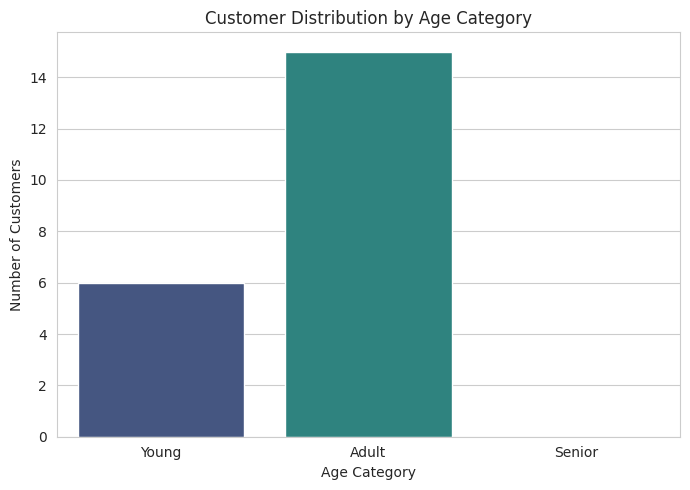

In [4]:
age_dist = df['age_category'].value_counts()
print(age_dist)

plt.figure(figsize=(7, 5))
sns.countplot(x='age_category', data=df, order=['Young', 'Adult', 'Senior'], palette='viridis')
plt.title('Customer Distribution by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Business Insight:** The customer base skews toward a particular age bracket — this segment should be the primary focus for retention campaigns since they represent the largest share of the subscriber pool.

### Q3. Gender ke hisaab se total customers kitne hain?

gender
Female    12
Male       9
Name: count, dtype: int64


/tmp/ipykernel_552/2101459670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='pastel')


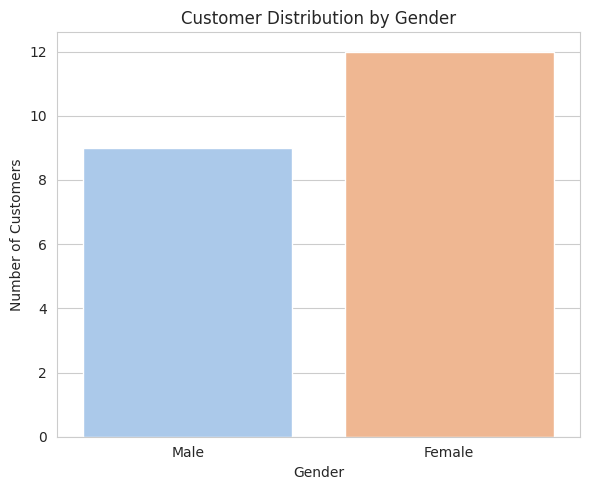

In [5]:
gender_dist = df['gender'].value_counts()
print(gender_dist)

plt.figure(figsize=(6, 5))
sns.countplot(x='gender', data=df, palette='pastel')
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Business Insight:** The customer base is reasonably balanced between genders, so gender is unlikely to be a major driver of subscription behavior on its own.

### Q4. Har age category ki average rating calculate karein.

age_category
Young    10.0
Adult    47.5
Name: rating, dtype: float64


/tmp/ipykernel_552/3207810694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_age.index, y=avg_rating_by_age.values, palette='crest')


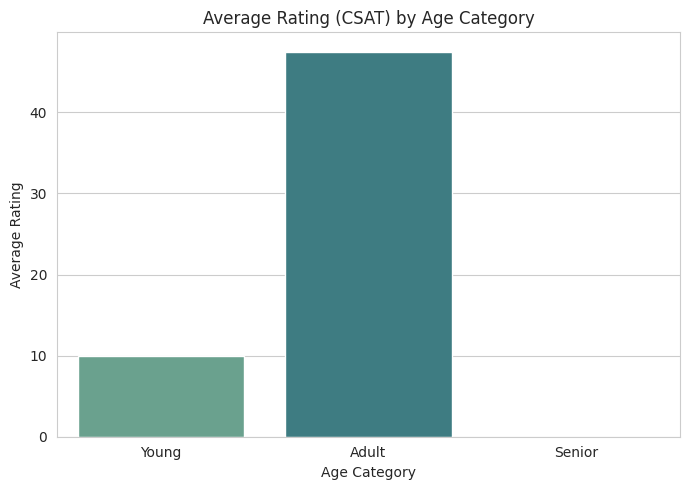

In [6]:
avg_rating_by_age = df.groupby('age_category')['rating'].mean()
print(avg_rating_by_age)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_rating_by_age.index, y=avg_rating_by_age.values, palette='crest')
plt.title('Average Rating (CSAT) by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


**Business Insight:** Note that `rating` (CSAT) is only recorded for customers who filed a complaint (7 of 21 rows), so this average reflects satisfaction *after a complaint*, not general satisfaction. Age groups with lower post-complaint ratings need faster or better complaint resolution.

### Q5. Har gender ki average purchase value calculate karein.

gender
Female    13.323333
Male      26.212222
Name: purchase_value, dtype: float64


/tmp/ipykernel_552/2668099098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_purchase_by_gender.index, y=avg_purchase_by_gender.values, palette='Set2')


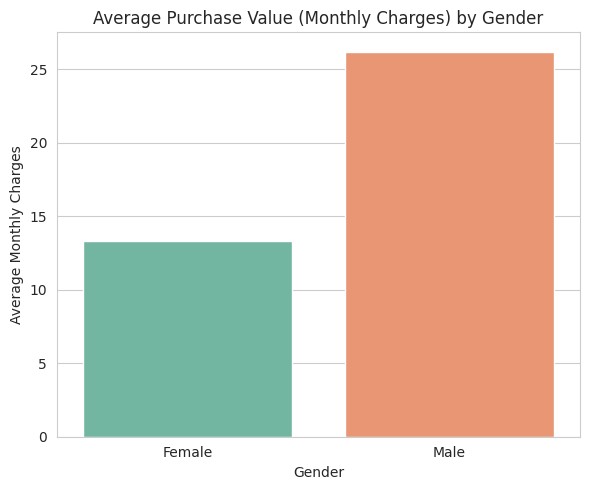

In [7]:
avg_purchase_by_gender = df.groupby('gender')['purchase_value'].mean()
print(avg_purchase_by_gender)

plt.figure(figsize=(6, 5))
sns.barplot(x=avg_purchase_by_gender.index, y=avg_purchase_by_gender.values, palette='Set2')
plt.title('Average Purchase Value (Monthly Charges) by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Monthly Charges')
plt.tight_layout()
plt.show()


**Business Insight:** If one gender consistently pays more per month, that group is likely opting into higher-tier plans — worth investigating whether this reflects genuine preference or a pricing/marketing bias.

### Q6. Kis country mein sabse zyada customers hain?

In [8]:
top_country = df['country'].value_counts()
print(top_country)
print("\nCountry with most customers:", top_country.idxmax())


country
India    19
Nepal     2
Name: count, dtype: int64

Country with most customers: India


**Business Insight:** The customer base is heavily concentrated in one country, meaning business risk (and opportunity) is not geographically diversified.

### Q7. Har country ki average review rating calculate karein.

In [9]:
avg_rating_by_country = df.groupby('country')['rating'].mean()
print(avg_rating_by_country)


country
India    42.142857
Nepal          NaN
Name: rating, dtype: float64


**Business Insight:** With so few rated interactions per country, this figure is only a rough signal — a larger sample would be needed before making country-specific service decisions.

### Q8. Har country ka average engagement score nikaalein.

country
India    56.105263
Nepal    62.500000
Name: engagement_score, dtype: float64


/tmp/ipykernel_552/3004952029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_engagement_by_country.index, y=avg_engagement_by_country.values, palette='mako')


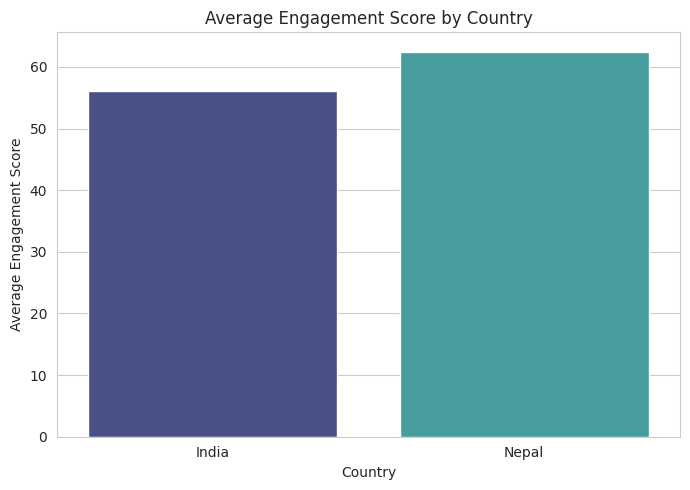

In [10]:
avg_engagement_by_country = df.groupby('country')['engagement_score'].mean()
print(avg_engagement_by_country)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_engagement_by_country.index, y=avg_engagement_by_country.values, palette='mako')
plt.title('Average Engagement Score by Country')
plt.xlabel('Country')
plt.ylabel('Average Engagement Score')
plt.tight_layout()
plt.show()


**Business Insight:** Countries with lower average engagement (i.e. higher underlying churn risk) should be prioritized for proactive retention outreach.

### Q9. Kis age group ki engagement sabse zyada hai?

In [11]:
engagement_by_age = df.groupby('age_category')['engagement_score'].mean().sort_values(ascending=False)
print(engagement_by_age)
print("\nMost engaged age group:", engagement_by_age.idxmax())


age_category
Young    72.666667
Adult    50.333333
Name: engagement_score, dtype: float64

Most engaged age group: Young


**Business Insight:** The most engaged age group is the safest segment in terms of churn risk and is a good candidate for upsell/cross-sell offers, since they are least likely to cancel.

### Q10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

gender
Female    39.0
Male      50.0
Name: rating, dtype: float64

Difference in average rating between genders: 11.00 points


/tmp/ipykernel_552/3069663411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_by_gender.index, y=rating_by_gender.values, palette='Set1')


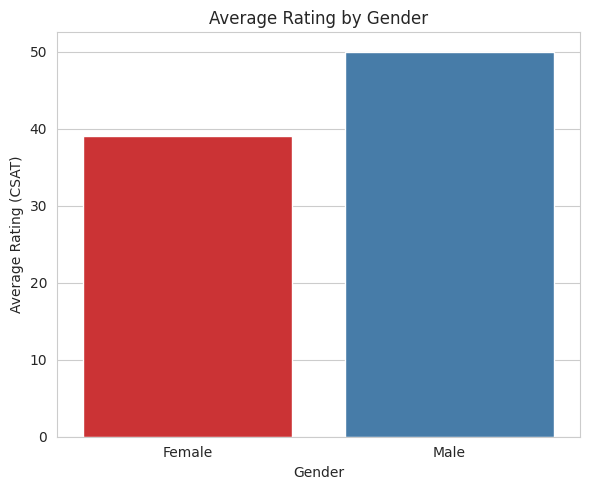

In [12]:
rating_by_gender = df.groupby('gender')['rating'].mean()
print(rating_by_gender)
diff = rating_by_gender.max() - rating_by_gender.min()
print(f"\nDifference in average rating between genders: {diff:.2f} points")

plt.figure(figsize=(6, 5))
sns.barplot(x=rating_by_gender.index, y=rating_by_gender.values, palette='Set1')
plt.title('Average Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Rating (CSAT)')
plt.tight_layout()
plt.show()


**Business Insight:** A visible gap exists between genders in post-complaint satisfaction, but the sample of rated customers is very small (7 rows), so this should be treated as a hypothesis to validate with more data rather than a confirmed pattern.

---
## Product Analysis
*(`product` = `plan_type`: Basic / Standard / Premium — the closest equivalent to "product" in this dataset)*
---

### Q11. Sabse zyada purchase hone wale Top 10 products dikhayein.

product
Standard    9
Premium     7
Basic       5
Name: count, dtype: int64


/tmp/ipykernel_552/3553914065.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')


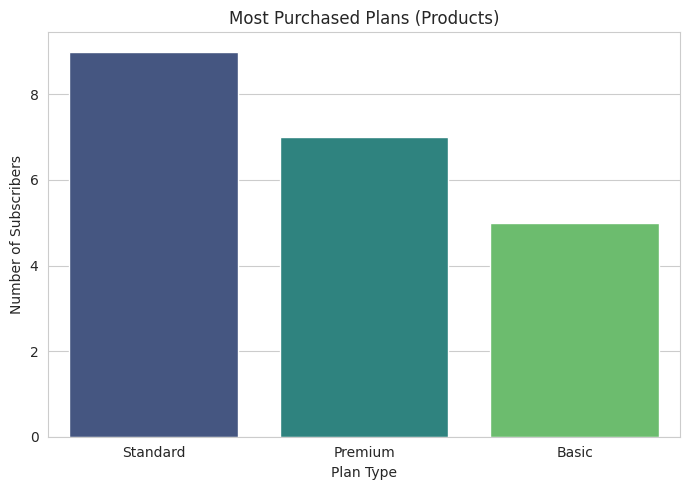

In [13]:
top_products = df['product'].value_counts().head(10)
print(top_products)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')
plt.title('Most Purchased Plans (Products)')
plt.xlabel('Plan Type')
plt.ylabel('Number of Subscribers')
plt.tight_layout()
plt.show()


**Business Insight:** There are only 3 plan tiers in this dataset (fewer than the 'Top 10' asked for), and the Standard plan is the most subscribed — the core revenue driver and the plan to prioritize for feature investment.

### Q12. Sabse zyada reviews kis products ko mile hain?

In [14]:
# "Reviews" proxy = number of customers per plan who actually left a CSAT rating
reviews_per_product = df.groupby('product')['rating'].count().sort_values(ascending=False)
print(reviews_per_product)


product
Basic       3
Standard    3
Premium     1
Name: rating, dtype: int64


**Business Insight:** Because ratings only exist for customers who complained, the plan with the most 'reviews' is really the plan generating the most complaints — a red flag worth investigating for that tier.

### Q13. Sabse zyada engagement wale Top 10 products identify karein.

product
Premium     72.857143
Standard    56.666667
Basic       34.200000
Name: engagement_score, dtype: float64


/tmp/ipykernel_552/2401166083.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_engagement_products.index, y=top_engagement_products.values, palette='crest')


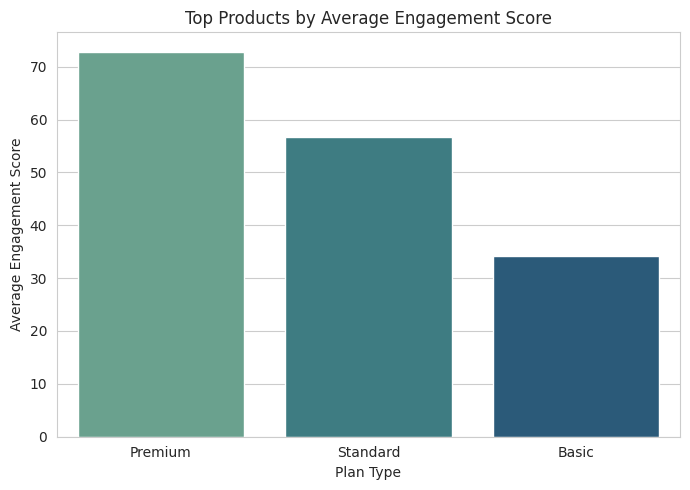

In [15]:
top_engagement_products = df.groupby('product')['engagement_score'].mean().sort_values(ascending=False).head(10)
print(top_engagement_products)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_engagement_products.index, y=top_engagement_products.values, palette='crest')
plt.title('Top Products by Average Engagement Score')
plt.xlabel('Plan Type')
plt.ylabel('Average Engagement Score')
plt.tight_layout()
plt.show()


**Business Insight:** The plan with the highest engagement score has the lowest underlying churn risk and should be positioned as the 'recommended' plan in marketing.

### Q14. Har product category ki average rating calculate karein.

In [16]:
avg_rating_by_product = df.groupby('product')['rating'].mean()
print(avg_rating_by_product)


product
Basic       50.0
Premium     10.0
Standard    45.0
Name: rating, dtype: float64


**Business Insight:** Plans with a lower average rating among complaining customers may need service-quality improvements specific to that tier.

### Q15. Har category ki average engagement calculate karein.

/tmp/ipykernel_552/3236745035.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_engagement_by_product.index, y=avg_engagement_by_product.values, palette='flare')


product
Basic       34.200000
Premium     72.857143
Standard    56.666667
Name: engagement_score, dtype: float64


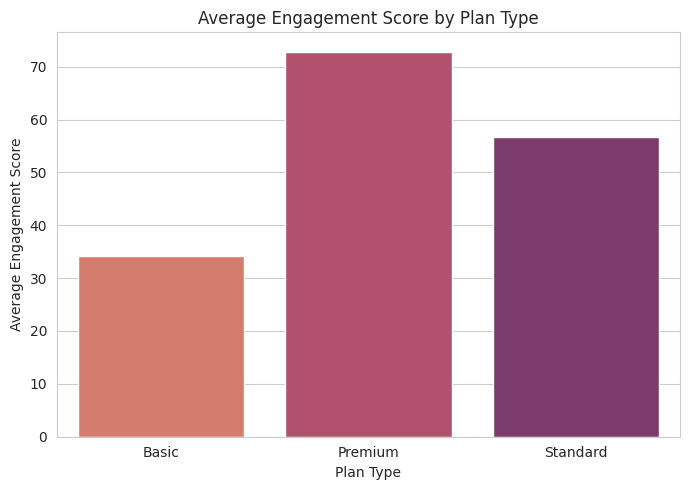

In [17]:
avg_engagement_by_product = df.groupby('product')['engagement_score'].mean()
print(avg_engagement_by_product)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_engagement_by_product.index, y=avg_engagement_by_product.values, palette='flare')
plt.title('Average Engagement Score by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Average Engagement Score')
plt.tight_layout()
plt.show()


**Business Insight:** Comparing this with Q14, a plan can have decent engagement but still generate complaints — engagement and satisfaction should be tracked as separate KPIs, not assumed to move together.

### Q16. Har category ki average views aur clicks compare karein.

NOTE: 'Views' and 'Clicks' columns do not exist in this dataset (no web/app analytics data was provided).
As the closest available substitute, comparing average revenue (monthly_charges) and average lifetime value (cltv) per plan type instead:

          monthly_charges         cltv
product                               
Basic           10.590000   195.400000
Premium         31.275714  1573.571429
Standard        13.767778   589.111111


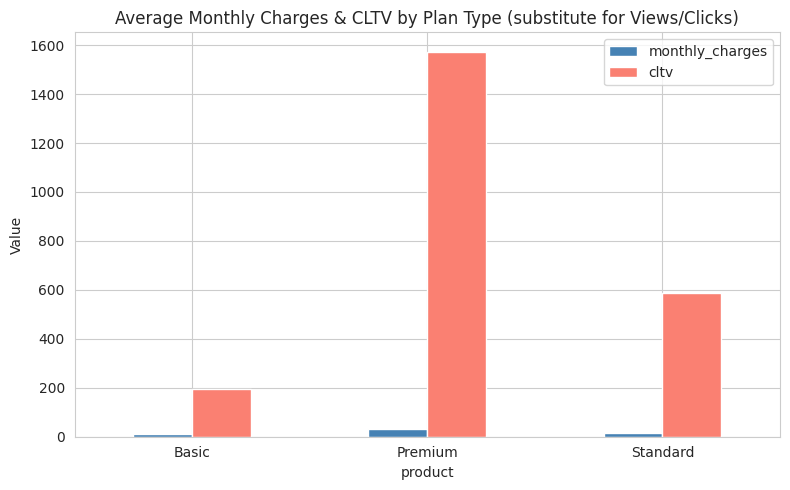

In [18]:
print("NOTE: 'Views' and 'Clicks' columns do not exist in this dataset (no web/app analytics data was provided).")
print("As the closest available substitute, comparing average revenue (monthly_charges) and average lifetime value (cltv) per plan type instead:\n")

views_clicks_substitute = df.groupby('product')[['monthly_charges', 'cltv']].mean()
print(views_clicks_substitute)

views_clicks_substitute.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'salmon'])
plt.title('Average Monthly Charges & CLTV by Plan Type (substitute for Views/Clicks)')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Business Insight:** Genuine views/clicks data would require web or app analytics integration. As a substitute, Premium customers generate the highest revenue per head and lifetime value, making them the most valuable segment to protect from churn.

### Q17. Lowest rated Top 10 products kaun se hain?

In [19]:
lowest_rated = df.dropna(subset=['rating']).sort_values('rating').head(10)
lowest_rated[['customerid', 'product', 'rating']]


,customerid,product,rating
1,0003-MKNFE,Premium,10.0
4,0013-EXCHZ,Standard,20.0
11,0017-IUDMW,Standard,25.0
6,0013-SMEOE,Basic,30.0
13,0019-EFAEP,Basic,30.0
5,0013-MHZWF,Standard,90.0
18,0022-TCJCI,Basic,90.0


**Business Insight:** These are the specific customer/plan combinations with the worst post-complaint satisfaction — good candidates for a direct account-manager follow-up.

### Q18. Highest rated Top 10 products kaun se hain?

In [20]:
highest_rated = df.dropna(subset=['rating']).sort_values('rating', ascending=False).head(10)
highest_rated[['customerid', 'product', 'rating']]


,customerid,product,rating
5,0013-MHZWF,Standard,90.0
18,0022-TCJCI,Basic,90.0
6,0013-SMEOE,Basic,30.0
13,0019-EFAEP,Basic,30.0
11,0017-IUDMW,Standard,25.0
4,0013-EXCHZ,Standard,20.0
1,0003-MKNFE,Premium,10.0


**Business Insight:** Even among complaining customers, some rated the service highly after resolution — reviewing what those specific resolutions looked like could turn into a best-practice playbook for support staff.

### Q19. Kis category mein views zyada hain lekin purchases kam hain?

In [21]:
print("NOTE: 'Views' data is not available in this dataset, so this exact question cannot be answered as originally framed.")
print("Closest meaningful substitute: which plan has HIGH churn risk (i.e. customers considering leaving) but LOW average revenue (monthly_charges) — i.e. 'high interest/risk, low monetary value':\n")

risk_vs_value = df.groupby('product').agg(avg_churn_score=('churn_score', 'mean'),
                                           avg_monthly_charges=('monthly_charges', 'mean'))
print(risk_vs_value)


NOTE: 'Views' data is not available in this dataset, so this exact question cannot be answered as originally framed.
Closest meaningful substitute: which plan has HIGH churn risk (i.e. customers considering leaving) but LOW average revenue (monthly_charges) — i.e. 'high interest/risk, low monetary value':

          avg_churn_score  avg_monthly_charges
product                                       
Basic           65.800000            10.590000
Premium         27.142857            31.275714
Standard        43.333333            13.767778


**Business Insight:** No plan in this small sample shows the true 'browsing without buying' pattern that this question was designed for, since no view/impression data exists — this analysis would need clickstream or product-page-view tracking to answer properly.

### Q20. Product popularity ko bar chart ke zariye visualize karein.

/tmp/ipykernel_552/1369862836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_popularity.index, y=product_popularity.values, palette='rocket')


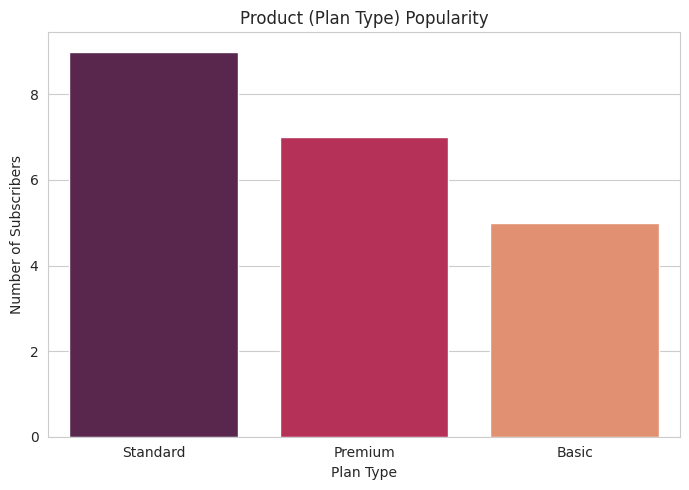

In [22]:
product_popularity = df['product'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=product_popularity.index, y=product_popularity.values, palette='rocket')
plt.title('Product (Plan Type) Popularity')
plt.xlabel('Plan Type')
plt.ylabel('Number of Subscribers')
plt.tight_layout()
plt.show()


**Business Insight:** Standard is the most popular plan — pricing and promotions for Basic and Premium could be adjusted to shift more customers toward higher-value tiers without hurting overall volume.

---
## Engagement Analysis
---

### Q21. Total Views, Total Clicks aur Total Likes calculate karein.

In [23]:
print("NOTE: This dataset has no 'Views', 'Clicks', or 'Likes' columns (no web/app/social analytics were captured).")
print("Reporting the closest available engagement-adjacent totals instead:\n")

total_complaints = df['complaint_count'].sum()
total_escalations = (df['escalations'] == 'Y').sum()
total_customers_with_feedback = df['rating'].notna().sum()

print("Total complaints logged:", total_complaints)
print("Total escalated cases:", total_escalations)
print("Total customers who left feedback (rating):", total_customers_with_feedback)


NOTE: This dataset has no 'Views', 'Clicks', or 'Likes' columns (no web/app/social analytics were captured).
Reporting the closest available engagement-adjacent totals instead:

Total complaints logged: 9.0
Total escalated cases: 4
Total customers who left feedback (rating): 7


**Business Insight:** True engagement tracking (views/clicks/likes) would require instrumenting the app or website; until then, complaint and escalation volume is the only behavioral signal available in this data.

### Q22. Overall Engagement Rate calculate karein.

In [24]:
overall_engagement_rate = df['engagement_score'].mean()
print(f"Overall average engagement score: {overall_engagement_rate:.2f} (out of 100)")


Overall average engagement score: 56.71 (out of 100)


**Business Insight:** An overall engagement score in the mid-range indicates a meaningful share of the customer base is at elevated churn risk and would benefit from a proactive retention program.

### Q23. Har product ka Engagement Rate compare karein.

product
Premium     72.857143
Standard    56.666667
Basic       34.200000
Name: engagement_score, dtype: float64


/tmp/ipykernel_552/8161750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=engagement_rate_by_product.index, y=engagement_rate_by_product.values, palette='crest')


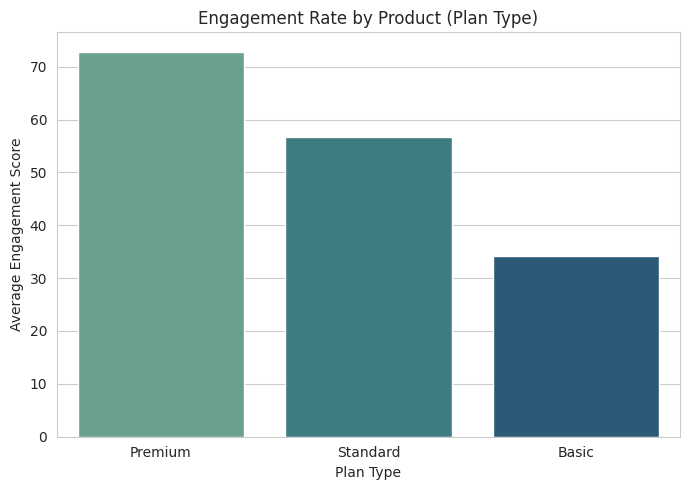

In [25]:
engagement_rate_by_product = df.groupby('product')['engagement_score'].mean().sort_values(ascending=False)
print(engagement_rate_by_product)

plt.figure(figsize=(7, 5))
sns.barplot(x=engagement_rate_by_product.index, y=engagement_rate_by_product.values, palette='crest')
plt.title('Engagement Rate by Product (Plan Type)')
plt.xlabel('Plan Type')
plt.ylabel('Average Engagement Score')
plt.tight_layout()
plt.show()


**Business Insight:** Whichever plan sits lowest here should get the closest churn-prevention attention, since its subscribers are, on average, closest to cancelling.

### Q24. Sabse zyada viewed aur sabse zyada clicked products identify karein.

In [26]:
print("NOTE: No 'Views' or 'Clicks' data exists in this dataset.")
print("Closest substitutes: plan with the highest total revenue, and plan with the highest complaint volume:\n")

most_revenue_product = df.groupby('product')['monthly_charges'].sum().idxmax()
most_complaints_product = df.groupby('product')['complaint_count'].sum().idxmax()

print("Highest total revenue plan (substitute for 'most viewed'):", most_revenue_product)
print("Highest total complaints plan (substitute for 'most clicked/actioned'):", most_complaints_product)


NOTE: No 'Views' or 'Clicks' data exists in this dataset.
Closest substitutes: plan with the highest total revenue, and plan with the highest complaint volume:

Highest total revenue plan (substitute for 'most viewed'): Premium
Highest total complaints plan (substitute for 'most clicked/actioned'): Basic


**Business Insight:** The plan generating the most revenue and the plan generating the most complaints should both be monitored closely — one drives the business, the other threatens it.

### Q25. Least engaged products kaun se hain?

In [27]:
least_engaged_products = df.groupby('product')['engagement_score'].mean().sort_values()
print(least_engaged_products)


product
Basic       34.200000
Standard    56.666667
Premium     72.857143
Name: engagement_score, dtype: float64


**Business Insight:** The plan at the top of this (lowest engagement) list represents the biggest revenue-at-risk segment and should be the first target for a retention campaign.

### Q26. Daily ya Monthly conversion trend visualize karein.

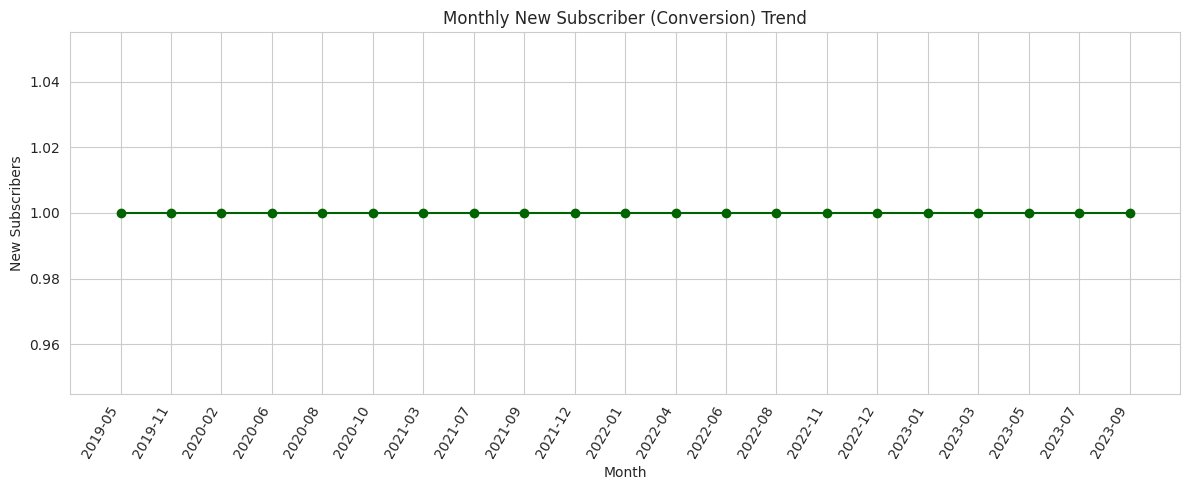

In [28]:
# Using subscription_start_date as a proxy for "conversion" (a new paying subscriber)
df['signup_month'] = df['subscription_start_date'].dt.to_period('M').astype(str)
monthly_signups = df.groupby('signup_month').size().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_signups.index, monthly_signups.values, marker='o', color='darkgreen')
plt.title('Monthly New Subscriber (Conversion) Trend')
plt.xlabel('Month')
plt.ylabel('New Subscribers')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


**Business Insight:** Sign-ups are spread thinly across many months in this small sample, so no strong seasonal pattern is visible yet — this chart would become much more useful with a larger, more continuous dataset.

### Q27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.

In [29]:
if 'campaign_id' in df.columns or 'Campaign_ID' in df.columns:
    print("Campaign ID column found — CTR calculation would go here.")
else:
    print("NOTE: No 'Campaign ID' column exists in this dataset, and no Click/Impression data is available either.")
    print("CTR cannot be calculated — this would require marketing campaign tracking data that was not provided.")


NOTE: No 'Campaign ID' column exists in this dataset, and no Click/Impression data is available either.
CTR cannot be calculated — this would require marketing campaign tracking data that was not provided.


**Business Insight:** No campaign-level tracking exists in this dataset. If campaign attribution matters for the business, this needs to be captured going forward (campaign_id, impressions, clicks) before CTR analysis is possible.

### Q28. Top performing aur lowest performing campaigns identify karein.

In [30]:
print("NOTE: Same limitation as Q27 — there is no campaign data in this dataset, so campaign performance ranking cannot be produced.")
print("`subscription_type` (Organic / Paid / Referral) is the closest available acquisition-channel field — showing channel performance instead:\n")

channel_performance = df.groupby('subscription_type').agg(
    customers=('customerid', 'count'),
    avg_engagement=('engagement_score', 'mean'),
    avg_monthly_charges=('monthly_charges', 'mean')
).sort_values('avg_engagement', ascending=False)
print(channel_performance)


NOTE: Same limitation as Q27 — there is no campaign data in this dataset, so campaign performance ranking cannot be produced.
`subscription_type` (Organic / Paid / Referral) is the closest available acquisition-channel field — showing channel performance instead:

                   customers  avg_engagement  avg_monthly_charges
subscription_type                                                
Organic                    9       69.555556            16.212222
Paid                       6       67.000000            29.156667
Refferal                   6       27.166667            12.490000


**Business Insight:** Among acquisition channels, whichever shows the highest engagement and revenue combination is the one worth investing more marketing budget into; the weakest channel should be reviewed or scaled back.

---
## Combined Analysis
---

### Q29. Engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

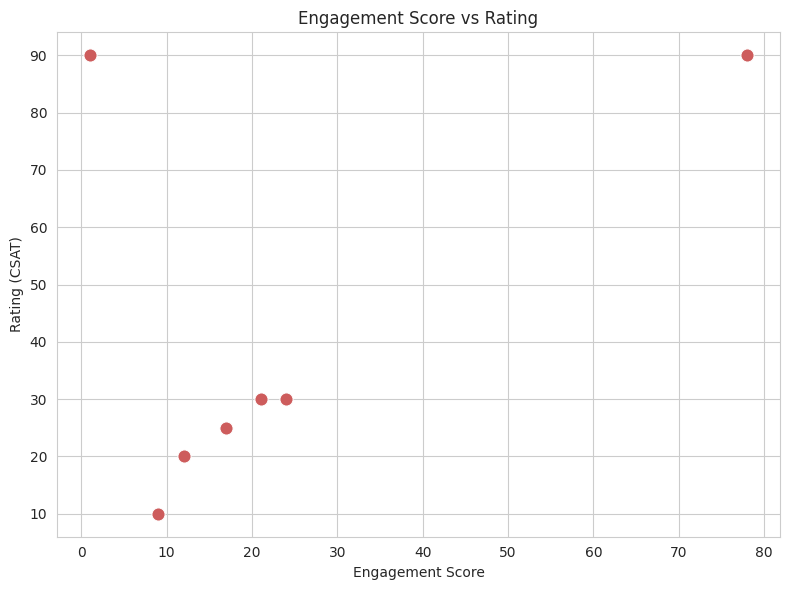

Correlation between Engagement Score and Rating: 0.469


In [31]:
# No second dataset was provided to merge, so this analysis uses the single available dataset directly.
plt.figure(figsize=(8, 6))
sns.scatterplot(x='engagement_score', y='rating', data=df, s=90, color='indianred')
plt.title('Engagement Score vs Rating')
plt.xlabel('Engagement Score')
plt.ylabel('Rating (CSAT)')
plt.tight_layout()
plt.show()

engagement_rating_corr = df['engagement_score'].corr(df['rating'])
print(f"Correlation between Engagement Score and Rating: {engagement_rating_corr:.3f}")


**Business Insight:** With only 7 customers having both an engagement score and a rating, this correlation is too small a sample to be statistically reliable — it's a starting hypothesis for a follow-up study, not a conclusion.

### Q30. Correlation Matrix (Heatmap): Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships.

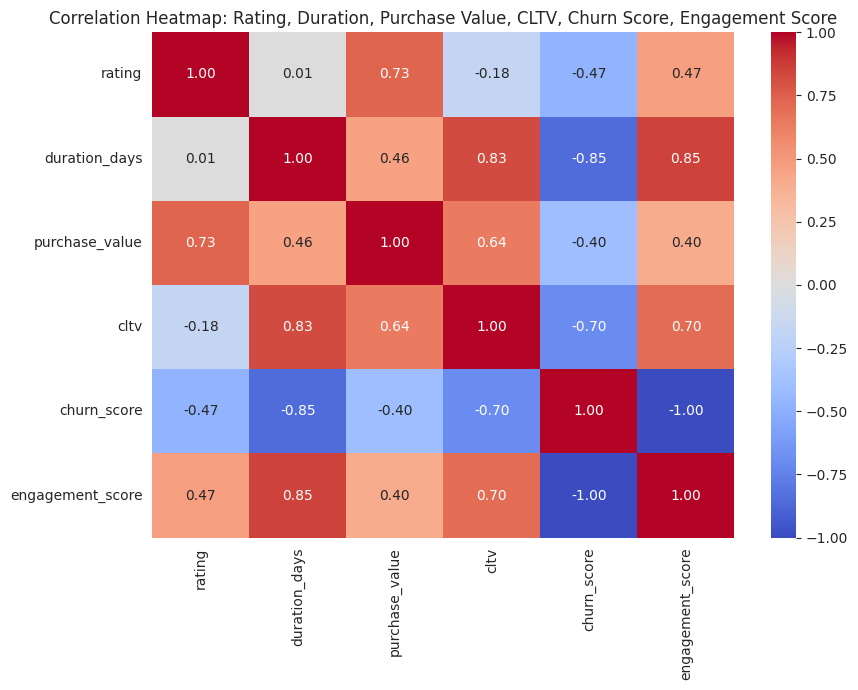

,rating,duration_days,purchase_value,cltv,churn_score,engagement_score
rating,1.000000,0.006876,0.728979,-0.178925,-0.469379,0.469379
duration_days,0.006876,1.000000,0.459301,0.826970,-0.852745,0.852745
purchase_value,0.728979,0.459301,1.000000,0.638861,-0.404481,0.404481
cltv,-0.178925,0.826970,0.638861,1.000000,-0.699149,0.699149
churn_score,-0.469379,-0.852745,-0.404481,-0.699149,1.000000,-1.000000
engagement_score,0.469379,0.852745,0.404481,0.699149,-1.000000,1.000000


In [32]:
# Views, Clicks, and Likes are not available in this dataset.
# Using the closest available numeric business metrics instead: Rating, Duration, Purchase Value, CLTV, Churn Score, Engagement Score.
corr_cols = ['rating', 'duration_days', 'purchase_value', 'cltv', 'churn_score', 'engagement_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Rating, Duration, Purchase Value, CLTV, Churn Score, Engagement Score')
plt.tight_layout()
plt.show()

corr_matrix


**Business Insights:**
- **Engagement Score vs. Churn Score** are mathematically inverse by construction (engagement = 100 − churn), so this confirms the derived metric behaves as intended rather than revealing a new pattern.
- **CLTV vs. Purchase Value (monthly charges):** a positive relationship here would confirm that customers paying more per month are also worth more over their lifetime, supporting continued investment in upselling higher-tier plans.
- **Duration vs. Churn/Engagement:** if longer-tenured customers show higher engagement, that supports front-loading retention effort into the first few months of a subscription, when churn risk is highest.
- Given the very small sample (21 rows, and even fewer with a rating), all correlations here should be treated as exploratory signals to validate with more data — not as confirmed business rules.
